# Un planeta que tapa más de la mitad de su estrella

Cuando un planeta pasa frente a su estrella, suele robarle menos del 1% de la luz. WD 1856 b le tapa **más de la mitad**. No porque sea gigante entre gigantes, sino porque su estrella es una enana blanca del tamaño de la Tierra — más pequeña que el propio planeta.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

El James Webb apuntó su espectrógrafo a ese tránsito descomunal y, por primera vez, leyó la atmósfera de un planeta que sobrevivió a la muerte de su estrella.

---

**Paper:** *Aerosols and hydrocarbons in the atmosphere of a white dwarf planet* · Nature (2026)  
**DOI:** [10.1038/s41586-026-10514-7](https://doi.org/10.1038/s41586-026-10514-7)  
**Instrumento:** JWST NIRSpec PRISM · espectroscopía de transmisión 0.5–5.0 μm

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-01-atmosfera-enana-blanca-wd1856/notebook.ipynb)

🎬 Video: _(próximamente)_

## De dónde salió este planeta

WD 1856+534 es una enana blanca: el núcleo desnudo y en enfriamiento de una estrella como el Sol, ya sin combustible. Del tamaño de la Tierra, pero con una masa parecida a la del Sol comprimida dentro.

A su alrededor gira WD 1856 b, un planeta gigante en una órbita apretadísima — a 0,02 unidades astronómicas, unas 50 veces más cerca que la Tierra del Sol. Cada vez que pasa por delante, eclipsa buena parte del diminuto disco de la enana. Ese eclipse gigante es lo que hace posible leer su atmósfera desde 25 pársecs de distancia.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEFF_EQUILIBRIO = 160        # Temperatura de equilibrio esperada (K) — del paper
CH4_ABUNDANCIA = 7           # Abundancia del candidato preferido, metano (%) — del ajuste del espectro (retrieval)
COLOR_DATOS      = '#2563EB'  # Azul CaM — pipeline FIREFLy
COLOR_SECUNDARIO = '#7C3AED'  # Violeta — pipeline Juniper
COLOR_ALERTA     = '#DC2626'  # Rojo — anomalía / referencia caliente
COLOR_REFERENCIA = '#D97706'  # Ámbar — expectativa teórica
FUENTE = ('Fuente: Vanderburg et al. (2026), Nature | '
          'Datos: Zenodo 10.5281/zenodo.18200586')

# ── Setup ──────────────────────────────────────────────────
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Carga de datos ─────────────────────────────────────────
espectro = pd.read_csv('datos/espectro_transmision.csv')
post_mp  = pd.read_csv('datos/posterior_mp.csv')
post_teff = pd.read_csv('datos/posterior_teff.csv')

print(f'Espectro de transmisión : {len(espectro)} puntos '
      f'({espectro.pipeline.nunique()} pipelines independientes)')
print(f'Posterior de masa       : {len(post_mp):,} muestras')
print(f'Posterior de temperatura: {len(post_teff):,} muestras')
print()
print('Rango de profundidad del tránsito: '
      f'{espectro.profundidad_pct.min():.1f}% – {espectro.profundidad_pct.max():.1f}%')

Espectro de transmisión : 254 puntos (2 pipelines independientes)
Posterior de masa       : 19,577 muestras
Posterior de temperatura: 19,577 muestras

Rango de profundidad del tránsito: 50.6% – 56.4%


Aquí está.

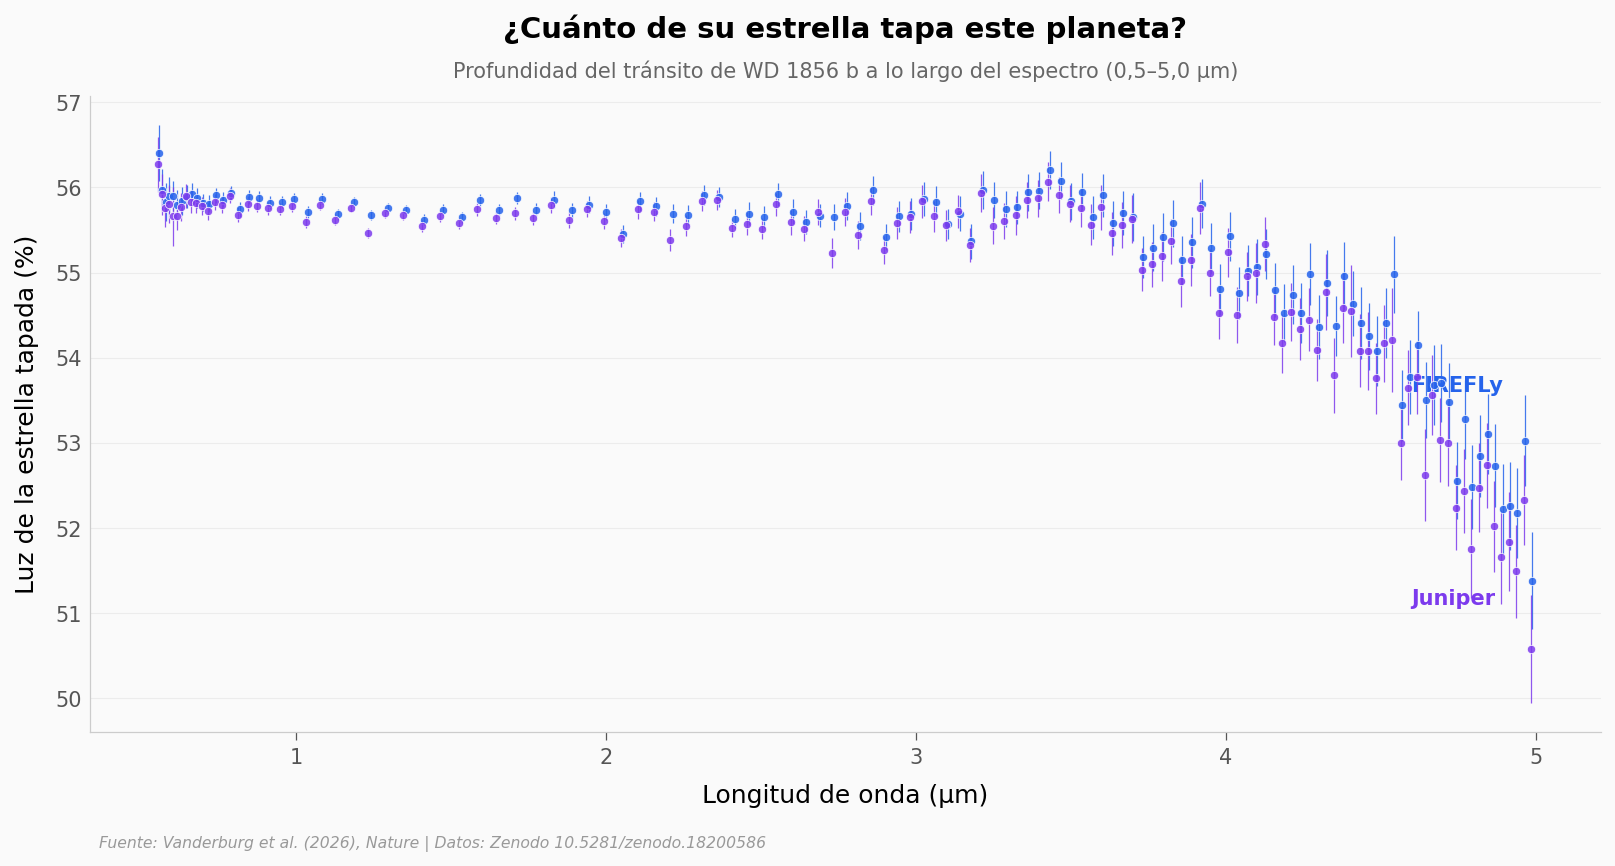

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

estilos = [('FIREFLy', COLOR_DATOS), ('Juniper', COLOR_SECUNDARIO)]
for nombre, color in estilos:
    d = espectro[espectro.pipeline == nombre].sort_values('wl_um')
    ax.errorbar(d.wl_um, d.profundidad_pct, yerr=d.profundidad_err_pct,
                fmt='o', ms=4, color=color, alpha=0.85,
                ecolor=color, elinewidth=0.6, capsize=0,
                markeredgecolor='white', markeredgewidth=0.4, zorder=5)

# Inline labels (reemplazan la leyenda)
ax.text(4.6, 53.6, 'FIREFLy', color=COLOR_DATOS, fontsize=10, fontweight='bold')
ax.text(4.6, 51.1, 'Juniper', color=COLOR_SECUNDARIO, fontsize=10, fontweight='bold')

ax.set_title('¿Cuánto de su estrella tapa este planeta?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Profundidad del tránsito de WD 1856 b a lo largo del espectro (0,5–5,0 μm)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Longitud de onda (μm)')
ax.set_ylabel('Luz de la estrella tapada (%)')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/espectro_transmision.png', dpi=200, bbox_inches='tight')
plt.show()

El eje vertical no miente: durante el tránsito desaparece más de la **mitad** de la luz. Es el tránsito más profundo medido hasta hoy — la marca de un planeta más grande que la estrella que orbita.

Y la línea no es plana. Sube y baja según la longitud de onda porque la atmósfera absorbe distinto en cada color. Esas ondulaciones son la huella química: donde el gas y las partículas en suspensión bloquean más luz, la profundidad aparente crece. Y no es casualidad: dos análisis independientes —FIREFLy y Juniper— dibujan exactamente la misma forma. Cuando dos equipos separados llegan al mismo dibujo, la huella es real.

## ¿Cuánto pesa lo que sobrevivió?

Un tránsito profundo dice el tamaño, no la masa. Para pesar el planeta, el equipo ajustó modelos de atmósfera a ese espectro y dejó que los datos votaran. El resultado no es un número: es una distribución de posibilidades.

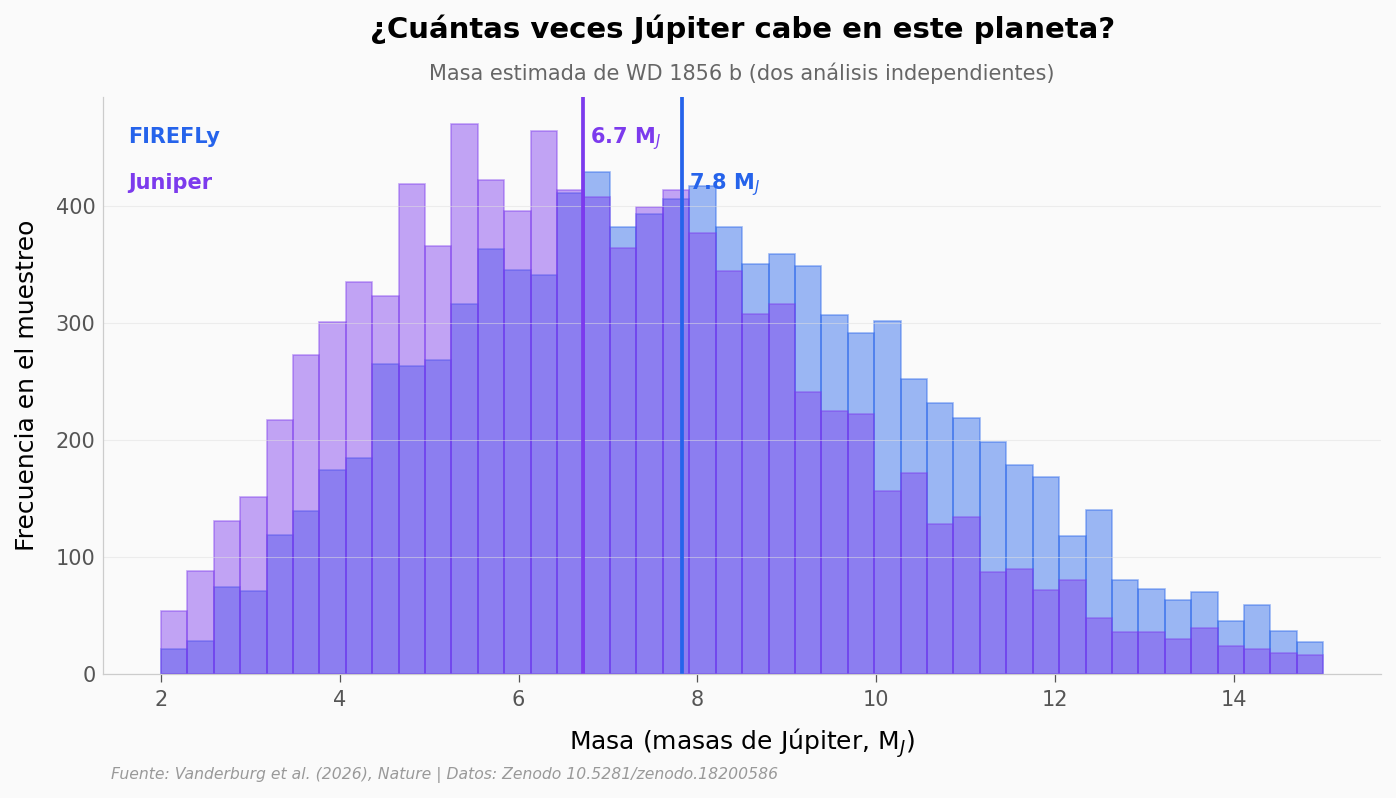

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

bins = np.linspace(2, 15, 45)
for nombre, color in estilos:
    v = post_mp.loc[post_mp.pipeline == nombre, 'valor'].values
    ax.hist(v, bins=bins, color=color, alpha=0.45,
            edgecolor=color, linewidth=0.8)
    med = np.median(v)
    ax.axvline(med, color=color, linewidth=1.8)
    ax.text(med, ax.get_ylim()[1]*0.92, f' {med:.1f} M$_J$',
            color=color, fontsize=10, fontweight='bold')

ax.text(0.02, 0.92, 'FIREFLy', transform=ax.transAxes,
        color=COLOR_DATOS, fontsize=10, fontweight='bold')
ax.text(0.02, 0.84, 'Juniper', transform=ax.transAxes,
        color=COLOR_SECUNDARIO, fontsize=10, fontweight='bold')

ax.set_title('¿Cuántas veces Júpiter cabe en este planeta?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Masa estimada de WD 1856 b (dos análisis independientes)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Masa (masas de Júpiter, M$_J$)')
ax.set_ylabel('Frecuencia en el muestreo')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/posterior_masa.png', dpi=200, bbox_inches='tight')
plt.show()

## El detalle que no cierra

Sabemos su tamaño y su masa: un gigante de varias veces Júpiter. Pero la enana blanca ya casi no calienta. A 0,02 unidades astronómicas, la cuenta da una temperatura de equilibrio de unos 160 K. Veamos qué temperatura leyó realmente el Webb.

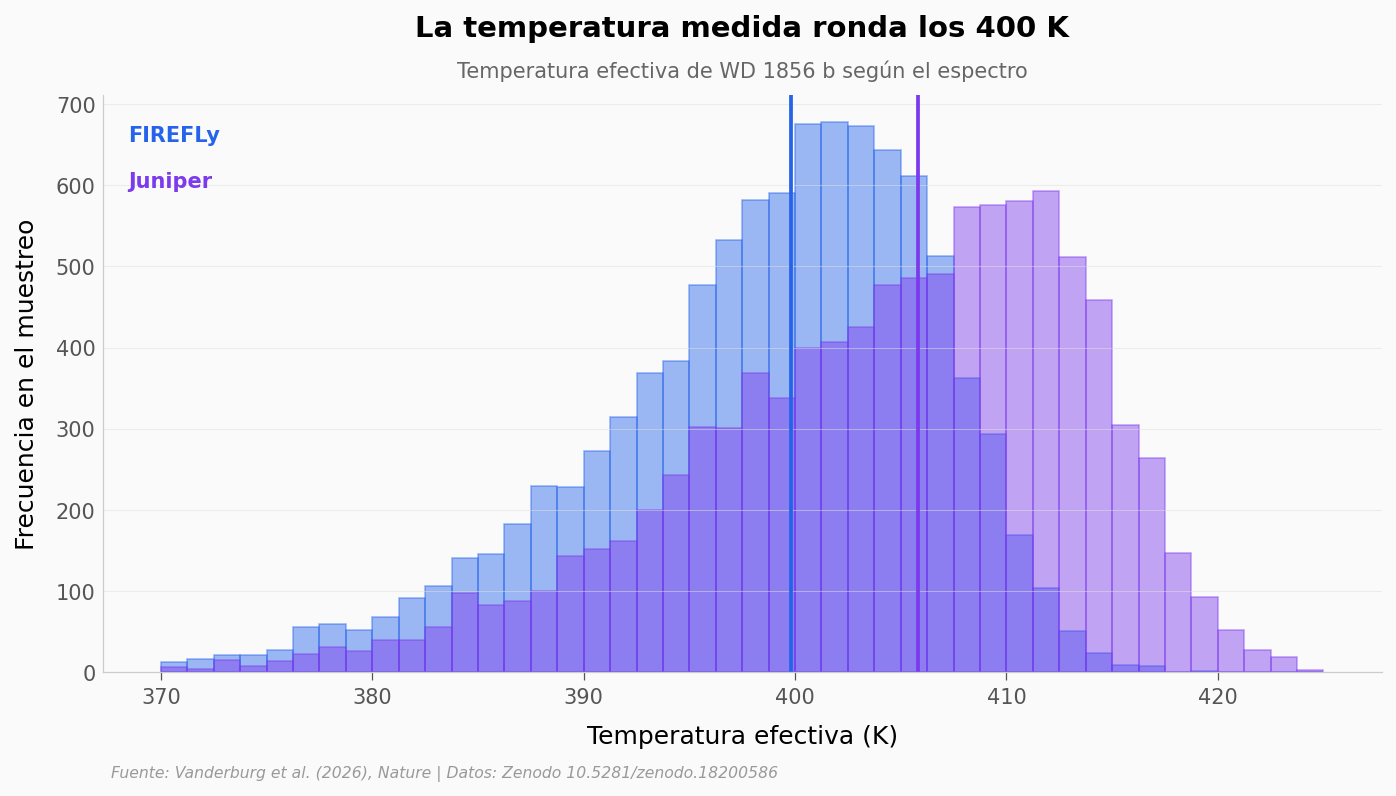

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

bins = np.linspace(370, 425, 45)
for nombre, color in estilos:
    v = post_teff.loc[post_teff.pipeline == nombre, 'valor'].values
    ax.hist(v, bins=bins, color=color, alpha=0.45,
            edgecolor=color, linewidth=0.8)
    med = np.median(v)
    ax.axvline(med, color=color, linewidth=1.8)

ax.text(0.02, 0.92, 'FIREFLy', transform=ax.transAxes,
        color=COLOR_DATOS, fontsize=10, fontweight='bold')
ax.text(0.02, 0.84, 'Juniper', transform=ax.transAxes,
        color=COLOR_SECUNDARIO, fontsize=10, fontweight='bold')

ax.set_title('La temperatura medida ronda los 400 K',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Temperatura efectiva de WD 1856 b según el espectro',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Temperatura efectiva (K)')
ax.set_ylabel('Frecuencia en el muestreo')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/posterior_teff.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan lejos está de lo esperado?

Los dos análisis coinciden en torno a los 400 K. Pero la física de un planeta calentado solo por una enana blanca fría predecía 160 K. Pongamos las dos cifras en la misma gráfica.

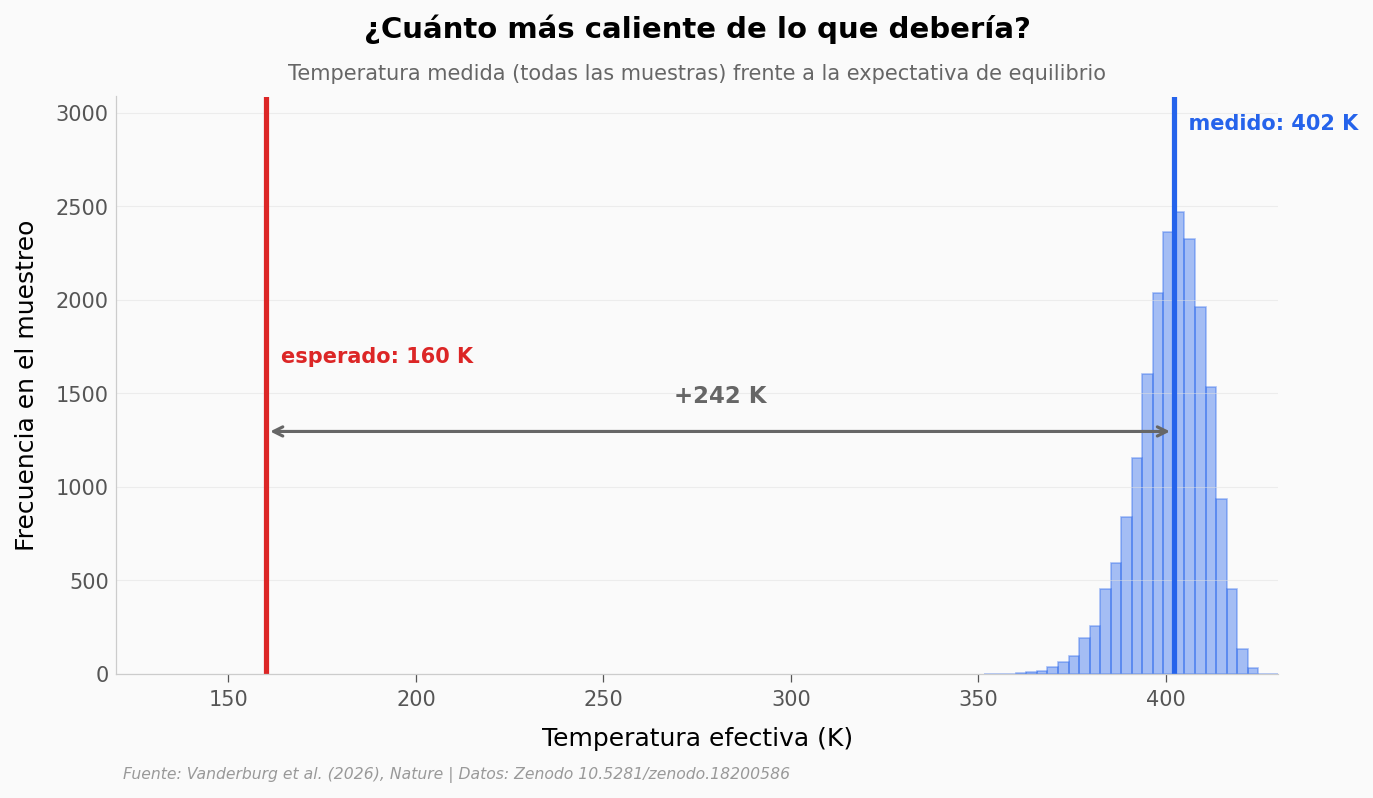

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

teff_todo = post_teff.valor.values          # ambos pipelines juntos
media = np.median(teff_todo)

n, bins, patches = ax.hist(teff_todo, bins=30, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Rango observado (medido) y expectativa teórica
ax.axvline(media, color=COLOR_DATOS, linewidth=2.5)
ax.axvline(TEFF_EQUILIBRIO, color=COLOR_ALERTA, linewidth=2.5)

ax.text(media, y_max*0.97, f'  medido: {media:.0f} K',
        color=COLOR_DATOS, fontsize=10, fontweight='bold', va='top')
ax.text(TEFF_EQUILIBRIO + 4, y_max*0.55, f'esperado: {TEFF_EQUILIBRIO} K',
        color=COLOR_ALERTA, fontsize=10, fontweight='bold', va='center')

# Flecha bidireccional mostrando la diferencia
ax.annotate('', xy=(media, y_max*0.42), xytext=(TEFF_EQUILIBRIO, y_max*0.42),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media + TEFF_EQUILIBRIO)/2, y_max*0.47,
        f'+{media - TEFF_EQUILIBRIO:.0f} K', color='#666666',
        fontsize=11, fontweight='bold', ha='center')

ax.set_title('¿Cuánto más caliente de lo que debería?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Temperatura medida (todas las muestras) frente a la expectativa de equilibrio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Temperatura efectiva (K)')
ax.set_ylabel('Frecuencia en el muestreo')
ax.set_xlim(120, 430)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_temperatura.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El tránsito tapa 51–56% de la estrella | ✅ | Directo del espectro (`espectro_transmision.csv`), consistente en ambos pipelines. Es el tránsito más profundo conocido. |
| Masa de 4,3–10,9 M_J | ✅ | Unión de los intervalos de 68% de ambos posteriores (`posterior_mp.csv`); medianas 7,8 (FIREFLy) y 6,7 (Juniper). |
| Temperatura ~390–412 K, muy por encima de los 160 K de equilibrio | ✅ | Posteriores de Teff (`posterior_teff.csv`); los 160 K son la expectativa teórica citada en el paper. |
| La atmósfera tiene aerosoles e hidrocarburos | ✅ | Detección directa en el paper (odds altísimos: aerosoles 2·10⁵:1 a 2·10⁶:1; hidrocarburos 167:1 a 5.377:1). No recomputado aquí. |
| El hidrocarburo dominante sería metano (CH₄, ~7%) | ⚠️ | El metano es el **candidato preferido**, pero con evidencia moderada (odds 17:1 a 30:1). No está confirmado. |
| Sufrió un recalentamiento hace 3,0–5,5 Gyr | ⚠️ | Inferencia del paper a partir de modelos de enfriamiento; los datos son consistentes con ello, no lo prueban. |

> **Limitaciones:** el espectro se ajusta con modelos de atmósfera, así que masa y temperatura dependen de esos supuestos (por eso hay dos pipelines). El metano es una preferencia estadística, no una detección firme. El recalentamiento y su origen por evolución de marea son una interpretación del equipo, no una medición.

## Ahora tú

1. **¿Cuánto discrepan los dos pipelines en la masa?** Compara las medianas de FIREFLy y Juniper. Pista: `post_mp.groupby('pipeline').valor.median()`.

2. **¿Dónde está la ondulación más marcada del espectro?** Busca en qué longitud de onda la profundidad cambia más rápido. Pista: ordena por `wl_um` y mira `.diff()` de `profundidad_pct`.

3. **¿Cuál es la probabilidad de que la temperatura real sea menor a 380 K?** Cuenta qué fracción del posterior cae por debajo. Pista: `(post_teff.valor < 380).mean()`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué tan de acuerdo están los dos análisis sobre la temperatura?
for nombre in ['FIREFLy', 'Juniper']:
    v = post_teff.loc[post_teff.pipeline == nombre, 'valor']
    lo, hi = v.quantile(0.16), v.quantile(0.84)
    print(f'{nombre:>8}: {v.median():.1f} K  (68% CI: {lo:.1f}-{hi:.1f} K)')

# Diferencia entre lo medido y lo esperado (media combinada):
gap = post_teff.valor.median() - TEFF_EQUILIBRIO
print(f'\nExceso sobre el equilibrio: +{gap:.0f} K '
      f'({gap / TEFF_EQUILIBRIO * 100:.0f}% por encima de lo previsto)')

 FIREFLy: 399.8 K  (68% CI: 390.4-406.2 K)
 Juniper: 405.8 K  (68% CI: 395.1-413.2 K)

Exceso sobre el equilibrio: +242 K (151% por encima de lo previsto)


## Fuentes

**Paper**: [Aerosols and hydrocarbons in the atmosphere of a white dwarf planet](https://doi.org/10.1038/s41586-026-10514-7)  
*Nature, 2026-07-01*

**Datos**: [Zenodo — materiales adicionales](https://doi.org/10.5281/zenodo.18200586)

*14 afirmaciones verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab). Licencia de datos según el repositorio original en Zenodo.*